<a href="https://colab.research.google.com/github/tungduong2106/PracticeML/blob/main/SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pyvi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 46.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 60.7 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_files
from pyvi import ViTokenizer
from sklearn import svm
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.model_selection import ShuffleSplit, learning_curve
%matplotlib inline

In [ ]:
from typing_extensions import Container
data_train = load_files(container_path = "/content/drive/MyDrive/Colab Notebooks/data (1)/news_1135 (1)", encoding = "utf-8")
print(data_train.filenames)
print()
print("Tong so file: {}" .format(len(data_train.filenames)))
print("Danh sach nhan va id tuong ung: ", [(idx,name) for idx,name in enumerate(data_train.target_names)])

['/content/drive/MyDrive/Colab Notebooks/data (1)/news_1135 (1)/Pháp luật/0e7537e00a4dd4c8c1b8d786858885c920311800.txt'
 '/content/drive/MyDrive/Colab Notebooks/data (1)/news_1135 (1)/Thời sự (1)/7ea376282b8acc4cb3784dbaa9fa995b52e57ce1.txt'
 '/content/drive/MyDrive/Colab Notebooks/data (1)/news_1135 (1)/Thể thao (1)/e78ef641b159653587e011d5929935b33e78c8d8 (1).txt'
 ...
 '/content/drive/MyDrive/Colab Notebooks/data (1)/news_1135 (1)/Tin kh†c/79a417e6e6db3325e0a9485fe4e7ed504f526ec7.txt'
 '/content/drive/MyDrive/Colab Notebooks/data (1)/news_1135 (1)/Thể thao (1)/5ee1dd38f31f2c61aa851907eddbc3d84dbad1b4 (1).txt'
 '/content/drive/MyDrive/Colab Notebooks/data (1)/news_1135 (1)/Thời sự (1)/4d983a17cb022cdb89d9ddcdfe6475b32f4673e1.txt']

Tong so file: 1027
Danh sach nhan va id tuong ung:  [(0, 'Khoa học - Công nghệ'), (1, 'Kinh tế'), (2, 'Pháp luật'), (3, 'Sức khỏe (1)'), (4, 'Thể thao (1)'), (5, 'Thời sự (1)'), (6, 'Tin kh†c'), (7, 'Đời sống - Xã hộ

In [ ]:
with open ("/content/drive/MyDrive/Colab Notebooks/data (1)/vietnamese-stopwords (1).txt", encoding="utf-8") as f:
  stopwords = f.readlines()
stopwords = [x.strip().replace(" ","_") for x in stopwords]
print("10 stopwords : ", stopwords[:10])

module_count_vector = CountVectorizer(stop_words = stopwords)
model_rf_preprocess = Pipeline([
    ('vect', module_count_vector),
    ('tfidf', TfidfTransformer())
])
data_preprocessed = model_rf_preprocess.fit_transform(data_train.data, data_train.target)
print("10 từ đầu tiên trong từ điển:")
i=0
for k,v in module_count_vector.vocabulary_.items():
  i+=1
  print(i, ": ",(k,v))
  if i>10:
    break
#

10 stopwords :  ['a_lô', 'a_ha', 'ai', 'ai_ai', 'ai_nấy', 'ai_đó', 'alô', 'amen', 'anh', 'anh_ấy']
10 từ đầu tiên trong từ điển:
1 :  ('dân_trí', 6637)
2 :  ('trình_báo', 18949)
3 :  ('sống', 17035)
4 :  ('lâu_năm', 11077)
5 :  ('chùa', 4684)
6 :  ('chiều', 4401)
7 :  ('tượng', 19801)
8 :  ('phật', 14925)
9 :  ('chánh', 4551)
10 :  ('điện', 22142)
11 :  ('nam', 12684)


In [ ]:
tfidf_vectorizer = TfidfVectorizer(stop_words=stopwords)
X_tfidf = tfidf_vectorizer.fit_transform(data_train.data)
feature_names = tfidf_vectorizer.get_feature_names_out()
# Lấy vector TF-IDF của văn bản đầu tiên
first_doc_vector = X_tfidf[0]
# Chuyển sang dạng (từ, giá trị tfidf)
import numpy as np
tfidf_scores = zip(feature_names, first_doc_vector.toarray()[0])
# Sắp xếp theo giá trị tfidf giảm dần
sorted_scores = sorted(tfidf_scores, key=lambda x: x[1], reverse=True)
# Hiển thị 10 từ có giá trị tfidf cao nhất trong văn bản đầu tiên
print("Top 10 từ trong văn bản đầu tiên:")
for word, score in sorted_scores[:10]:
    print(word, ":", score)

Top 10 từ trong văn bản đầu tiên:
chùa : 0.40240861872588835
tượng : 0.31647969464881753
trình_báo : 0.24144517123553305
vàng : 0.20097792849811671
phật : 0.19536838237128315
công_an : 0.19386508051179627
đục : 0.1871475297626935
thủ_đức : 0.18077094108520872
cất_giấu : 0.17115585231526417
cột : 0.17115585231526417


In [ ]:
from sklearn.model_selection import ShuffleSplit
X_train, X_test, y_train, y_test = train_test_split(data_preprocessed, data_train.target, test_size=0.2)
print("Dữ liệu training: ", X_train.shape, y_train.shape)
print("Dữ liệu testing: ", X_test.shape, y_test.shape)
print("Danh sách nhãn và id tương ứng: ", [(idx, name) for idx, name in enumerate(data_train.target_names)] )

Dữ liệu training:  (821, 23343) (821,)
Dữ liệu testing:  (206, 23343) (206,)
Danh sách nhãn và id tương ứng:  [(0, 'Khoa học - Công nghệ'), (1, 'Kinh tế'), (2, 'Pháp luật'), (3, 'Sức khỏe (1)'), (4, 'Thể thao (1)'), (5, 'Thời sự (1)'), (6, 'Tin kh†c'), (7, 'Đời sống - Xã hội'), (8, 'Độc giả')]


In [ ]:
print("- Training ...")
print("- Train size = {}".format(X_train.shape))
model = svm.SVC(kernel='linear', C=1)
model.fit(X_train, y_train)
print("- model - train complete")

- Training ...
- Train size = (821, 23343)
- model - train complete


In [ ]:
from sklearn.metrics import accuracy_score
print("- Testing ...")
y_test_pred = model.predict(X_test)
y_train_pred = model.predict(X_train)
print("- Test Acc = {}".format(accuracy_score(y_test, y_test_pred)))
print("- Train Acc = {}".format(accuracy_score(y_train, y_train_pred)))


- Testing ...
- Test Acc = 0.883495145631068
- Train Acc = 0.9951278928136419


In [ ]:
print("- Train size = {}".format(X_train.shape))
model_2 = svm.SVC(kernel='rbf', C=1)
model_2.fit(X_train, y_train)

- Train size = (821, 23343)


SVC(C=1)

In [ ]:
# Tiền xử lý dữ liệu sử dụng module model_rf_preprocess.
new_doc = "Công phượng ghi bàn cho đội tuyển Việt nam"
# tách từ sử dụng pyvi
tokenized_new_doc = ViTokenizer.tokenize(new_doc)
# văn bản ở dạng mảng/vector
tokenized_new_doc = [tokenized_new_doc]
print(tokenized_new_doc)
# module model_rf_preprocess
input_data_preprocessed = model_rf_preprocess.transform(tokenized_new_doc)
print(input_data_preprocessed)

['Công phượng ghi_bàn cho đội_tuyển Việt_nam']
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 5 stored elements and shape (1, 23343)>
  Coords	Values
  (0, 5604)	0.3259420645757043
  (0, 7434)	0.4571409262822909
  (0, 14857)	0.6494454479437373
  (0, 20576)	0.23243650255677087
  (0, 23104)	0.4571409262822909


In [ ]:
prediction = model.predict(input_data_preprocessed)
predicted_label_id = prediction[0]
print("ID nhãn dự đoán: ",predicted_label_id)
target_names = data_train.target_names
print("Tên nhãn dự đoán: ",target_names[predicted_label_id])

ID nhãn dự đoán:  4
Tên nhãn dự đoán:  Thể thao (1)


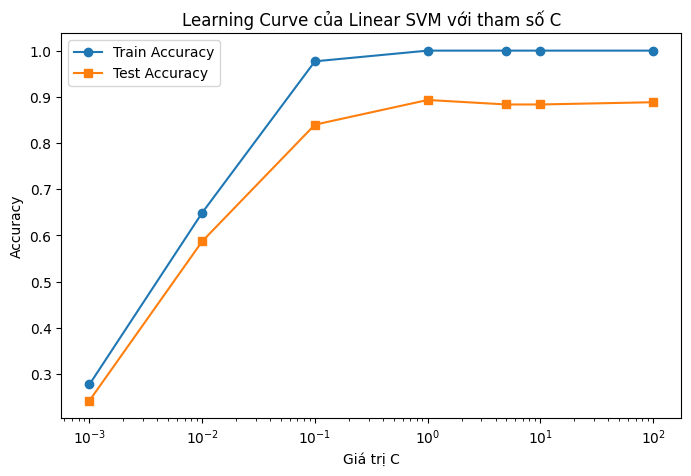

In [ ]:
import matplotlib.pyplot as plt
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score
list_C = [0.001, 0.01, 0.1, 1, 5.0, 10.0, 100]
train_acc = []
test_acc = []
for C in list_C:
    model = LinearSVC(C=C, max_iter=10000)
    model.fit(X_train, y_train)
    # Accuracy trên tập train
    y_train_pred = model.predict(X_train)
    train_acc.append(accuracy_score(y_train, y_train_pred))
    # Accuracy trên tập test
    y_test_pred = model.predict(X_test)
    test_acc.append(accuracy_score(y_test, y_test_pred))
# Vẽ biểu đồ
plt.figure(figsize=(8,5))
plt.plot(list_C, train_acc, marker='o', label='Train Accuracy')
plt.plot(list_C, test_acc, marker='s', label='Test Accuracy')
plt.xscale('log')  # trục C thường vẽ theo log scale
plt.xlabel('Giá trị C')
plt.ylabel('Accuracy')
plt.title('Learning Curve của Linear SVM với tham số C')
plt.legend()
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
params_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'gamma': [0.0001, 0.001, 0.01, 0.1],
    'kernel': ['linear', 'rbf', 'poly']
}
svm_model = SVC()
grid_search = GridSearchCV(
    estimator=svm_model,
    param_grid=params_grid,
    cv=5,              # 5-fold cross-validation
    scoring='accuracy',
    n_jobs=-1          # chạy song song cho nhanh
)
grid_search.fit(data_preprocessed, data_train.target)
print("Best parameters:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)

Best parameters: {'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}
Best cross-validation accuracy: 0.8733933222827375


Dữ liệu training =  (1437, 64) (1437,)
Dữ liệu testing =  (360, 64) (360,)


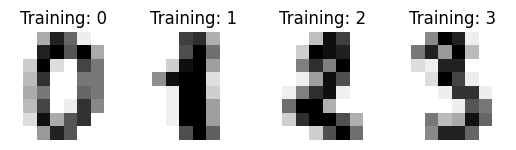

In [ ]:
# Standard scientific Python imports
import matplotlib.pyplot as plt
# Import datasets, classifiers and performance metrics
from sklearn import datasets, svm, metrics
# The digits dataset
digits = datasets.load_digits()
# The data that we are interested in is made of 8x8 images of digits, let's
# have a look at the first 4 images, stored in the `images` attribute of the
# dataset.  If we were working from image files, we could load them using
# matplotlib.pyplot.imread.  Note that each image must have the same size. For these
# images, we know which digit they represent: it is given in the 'target' of
# the dataset.
images_and_labels = list(zip(digits.images, digits.target))
for index, (image, label) in enumerate(images_and_labels[:4]):
    plt.subplot(2, 4, index + 1)
    plt.axis('off')
    plt.imshow(image, cmap=plt.cm.gray_r, interpolation='nearest')
    plt.title('Training: %i' % label)
# To apply a classifier on this data, we need to flatten the image, to
# turn the data in a (samples, feature) matrix:
n_samples = len(digits.images)
data = digits.images.reshape((n_samples, -1))
target = digits.target
# Define test_size before using it
test_size = 0.2 # You can adjust this value as needed
X_train, X_test, y_train, y_test = train_test_split( data, target, test_size=test_size)
print("Dữ liệu training = ", X_train.shape, y_train.shape)
print("Dữ liệu testing = ", X_test.shape, y_test.shape)


In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
model = SVC(kernel='linear', C=1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification report:\n", classification_report(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.975
Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        40
           1       0.94      0.97      0.95        31
           2       1.00      1.00      1.00        35
           3       1.00      0.97      0.99        39
           4       0.98      1.00      0.99        43
           5       1.00      0.95      0.97        39
           6       1.00      0.97      0.98        32
           7       1.00      0.94      0.97        36
           8       0.91      0.97      0.94        32
           9       0.91      0.97      0.94        33

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.98      0.97      0.98       360

Confusion matrix:
 [[40  0  0  0  0  0  0  0  0  0]
 [ 0 30  0  0  0  0  0  0  1  0]
 [ 0  0 35  0  0  0  0  0  0  0]
 [ 0  0  0 38  0  0  0  0  1  0]
 [ 0  0  0  0 43  0  0  0  0  0]
 [ 0  0  0  0  0 

In [ ]:
best_model = grid_search.best_estimator_
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)
print("Accuracy với tham số tối ưu:", accuracy_score(y_test, y_pred_best))


Accuracy với tham số tối ưu: 0.8333333333333334
